In [1]:
import numpy as np
import math 
import matplotlib.pyplot as plt
from scipy import special
from joblib import Parallel, delayed

    """
    Time-varying, participant-specific contextual bandit environment.

    Reward model:
        R_{i,t}(a) = theta_{i,a,0} + theta_{i,a,1} * c_{i,t} + eps_{i,t,a}

    where
        c_{i,t} ~ Bernoulli(p_context)
        eps_{i,t,a} ~ Normal(0, sigma_a^2)

    Participant-level parameters are drawn from
        theta_{i,a} ~ Normal(mu_a, Covariance)

    for each arm a, where theta_{i,a} is a 2-vector:
        theta_{i,a} = [theta_{i,a,0}, theta_{i,a,1}]
    """

In [45]:
from dataclasses import dataclass

@dataclass
class ContextualEnvironment:
    n_participants: int
    n_arms: int
    T: int
    p_context: float
    mu_a: np.ndarray          # shape (n_arms, 2)
    covariance: np.ndarray       # shape (n_arms, 2, 2)
    sigma_a: np.ndarray       # shape (n_arms,)
    seed: int=0

    def __post_init__(self) -> None:
        self.rng = np.random.default_rng(self.seed)

        self.mu_a = np.asarray(self.mu_a, dtype=float)
        self.covariance = np.asarray(self.covariance, dtype=float)
        self.sigma_a = np.asarray(self.sigma_a, dtype=float)

        # Draw participant-level parameters theta_{i,a}
        # theta shape: (n_participants, n_arms, 2)
        self.theta = np.zeros((self.n_participants, self.n_arms, 2), dtype=float)
        for a in range(self.n_arms):
            self.theta[:, a, :] = self.rng.multivariate_normal(
                mean=self.mu_a[a],
                cov=self.covariance[a],
                size=self.n_participants,
            )

        # Draw contexts c_{i,t}
        # shape: (n_participants, T)
        self.context = self.rng.binomial(
            n=1,
            p=self.p_context,
            size=(self.n_participants, self.T),
        ).astype(int)
    
    def get_context(self, i, t):
        return int(self.context[i, t])

    def context_vector(self, i, t):
        c_it = self.get_context(i, t)
        return np.array([1.0, float(c_it)])

    def expected_reward(self, i, t, a):
        x_it = self.context_vector(i, t)
        return float(x_it @ self.theta[i, a])

    def sample_reward(self, i, t, a):
        mean = self.expected_reward(i, t, a)
        return float(self.rng.normal(loc=mean, scale=self.sigma_a[a]))

    def best_arm(self, i, t):
        r0 = self.expected_reward(i, t, 0)
        r1 = self.expected_reward(i, t, 1)
        return int(r1 > r0)

    def regret(self, i, t, a_sel):
        best = max(self.expected_reward(i, t, 0), self.expected_reward(i, t, 1))
        chosen = self.expected_reward(i, t, a_sel)
        return float(best - chosen)


In [41]:
class RidgeLearningAlgorithm:
    """
    Learns participant-specific contextual parameters for each arm.

    For each participant i and arm a, keeps all past:
        (x_{i,j}, r_{i,a,j})

    Then computes:
        theta_hat_{i,a,t}
        Sigma_{i,a,t}
    """
    def __init__(self, n_participants, lam=1e-6):
        self.n_participants = n_participants
        self.lam = lam

        # store observations by participant and arm
        self.X = {(i, a): [] for i in range(n_participants) for a in range(2)}
        self.y = {(i, a): [] for i in range(n_participants) for a in range(2)}

    def update(self, i, a, x, r):
        self.X[(i, a)].append(np.asarray(x, dtype=float))
        self.y[(i, a)].append(float(r))

    def _ridge_estimate_single(self, i, a):
        X_list = self.X[(i, a)]
        y_list = self.y[(i, a)]

        d = 2
        I = np.eye(d)

        if len(X_list) == 0:
            theta_hat = np.zeros(d)
            gram_inv = np.linalg.inv(self.lam * I)
            return theta_hat, gram_inv, 0

        X = np.vstack(X_list)              # shape (n_obs, 2)
        y = np.asarray(y_list)             # shape (n_obs,)

        gram = self.lam * I + X.T @ X
        gram_inv = np.linalg.inv(gram)
        theta_hat = gram_inv @ (X.T @ y)

        return theta_hat, gram_inv, len(y)

    def estimate_sigma2_per_arm(self):
        """
        Residual variance estimate pooled across participants for each arm:
            sigma_hat_a^2 = sum_i sum_j (r_{i,a,j} - x_{i,j}^T beta_hat_{i,a})^2
                            / sum_i (n_{i,a} - 2)
        """
        sigma2_hat = np.zeros(2)

        for a in range(2):
            rss = 0.0
            denom = 0

            for i in range(self.n_participants):
                X_list = self.X[(i, a)]
                y_list = self.y[(i, a)]

                if len(X_list) == 0:
                    continue

                X = np.vstack(X_list)
                y = np.asarray(y_list)

                theta_hat, _, n_obs = self._ridge_estimate_single(i, a)
                residuals = y - X @ theta_hat
                rss += float(np.sum(residuals ** 2))

                # 2 parameters in contextual model
                denom += max(n_obs - 2, 0)

            if denom > 0:
                sigma2_hat[a] = rss / denom
            else:
                sigma2_hat[a] = 1.0  # fallback

        return sigma2_hat

    def get_participant_estimates(self):
        """
        Returns:
            theta_hat[i][a] : shape (2,)
            Sigma_hat[i][a] : shape (2,2)
        """
        sigma2_hat = self.estimate_sigma2_per_arm()

        theta_hat = [[None for _ in range(2)] for _ in range(self.n_participants)]
        Sigma_hat = [[None for _ in range(2)] for _ in range(self.n_participants)]

        for i in range(self.n_participants):
            for a in range(2):
                beta_hat, gram_inv, _ = self._ridge_estimate_single(i, a)
                theta_hat[i][a] = beta_hat
                Sigma_hat[i][a] = sigma2_hat[a] * gram_inv

        return theta_hat, Sigma_hat, sigma2_hat

In [33]:
class EmpiricalBayesActionSelector:
    """
    Uses participant-level estimates (theta_hat_{i,a,t}, Sigma_{i,a,t})
    and pools across participants to estimate population hyperparameters
    for each arm.

    Then computes posterior for participant i and uses the posterior
    probability that arm 1 yields larger reward than arm 0.
    """
    def __init__(self, jitter=1e-6):
        self.jitter = jitter

    def estimate_hyperparams(self, theta_hat, Sigma_hat):
        """
        Estimate mu_hat[a] and Sigma_pop_hat[a] for each arm a.

        Input:
            theta_hat[i][a] : vector length 2
            Sigma_hat[i][a] : 2x2 covariance

        Output:
            mu_hat[a] : vector length 2
            Sigma_pop_hat[a] : 2x2 covariance
        """
        n = len(theta_hat)
        mu_hat = [None, None]
        Sigma_pop_hat = [None, None]

        for a in range(2):
            B = np.vstack([theta_hat[i][a] for i in range(n)])      # (n,2)
            Sbar = sum(Sigma_hat[i][a] for i in range(n)) / n       # average within-person covariance

            mu_a = np.mean(B, axis=0)

            # observed covariance of beta-hats
            if n > 1:
                centered = B - mu_a
                cov_obs = centered.T @ centered / (n - 1)
            else:
                cov_obs = np.eye(2)

            # method-of-moments correction:
            # Cov(beta_hat) ≈ Sigma_pop + average(Sigma_i)
            Sigma_a = cov_obs - Sbar

            # stabilize
            Sigma_a = 0.5 * (Sigma_a + Sigma_a.T)
            eigvals, eigvecs = np.linalg.eigh(Sigma_a)
            eigvals = np.maximum(eigvals, self.jitter)
            Sigma_a = eigvecs @ np.diag(eigvals) @ eigvecs.T

            mu_hat[a] = mu_a
            Sigma_pop_hat[a] = Sigma_a

        return mu_hat, Sigma_pop_hat

    def posterior_single_arm(self, beta_hat_i_a, Sigma_i_a, mu_a, Sigma_a):
        """
        Posterior:
            theta_{i,a} | beta_hat_{i,a} ~ N(m_post, V_post)

        with
            V_post = (Sigma_a^{-1} + Sigma_i_a^{-1})^{-1}
            m_post = V_post (Sigma_a^{-1} mu_a + Sigma_i_a^{-1} beta_hat_i_a)
        """
        Sigma_a_inv = np.linalg.inv(Sigma_a)
        Sigma_i_inv = np.linalg.inv(Sigma_i_a)

        V_post = np.linalg.inv(Sigma_a_inv + Sigma_i_inv)
        m_post = V_post @ (Sigma_a_inv @ mu_a + Sigma_i_inv @ beta_hat_i_a)

        return m_post, V_post

    def choose_action(self, i, x_it, theta_hat, Sigma_hat, rng=None):
        """
        Choose arm for participant i at context x_it.

        Uses the posterior distribution of x_it^T theta_{i,a} for each arm.
        """
        if rng is None:
            rng = np.random.default_rng()

        mu_hat, Sigma_pop_hat = self.estimate_hyperparams(theta_hat, Sigma_hat)

        m_post = [None, None]
        V_post = [None, None]

        for a in range(2):
            m_post[a], V_post[a] = self.posterior_single_arm(
                beta_hat_i_a=theta_hat[i][a],
                Sigma_i_a=Sigma_hat[i][a],
                mu_a=mu_hat[a],
                Sigma_a=Sigma_pop_hat[a]
            )

        # Posterior distribution of reward for each arm:
        # x^T theta_{i,a} ~ N(x^T m_post[a], x^T V_post[a] x)
        means = np.array([x_it @ m_post[a] for a in range(2)])
        vars_ = np.array([x_it @ V_post[a] @ x_it for a in range(2)])
        vars_ = np.maximum(vars_, 1e-8)

        # Thompson-style sampling
        sampled = rng.normal(loc=means, scale=np.sqrt(vars_))
        a_sel = int(np.argmax(sampled))

        return a_sel, {
            "mu_hat": mu_hat,
            "Sigma_pop_hat": Sigma_pop_hat,
            "m_post": m_post,
            "V_post": V_post,
            "reward_means": means,
            "reward_vars": vars_,
        }

In [51]:
class UnpooledContextualTS:
    """
    Thompson sampling using participant-specific ridge estimates only.
    No pooling across participants.
    """

    def choose_action(self, i, x_it, theta_hat, Sigma_hat, rng=None):
        if rng is None:
            rng = np.random.default_rng()

        sampled_rewards = np.zeros(2)

        for a in range(2):
            mean_a = theta_hat[i][a]
            cov_a = Sigma_hat[i][a]

            # stabilize covariance
            cov_a = 0.5 * (cov_a + cov_a.T)
            cov_a = cov_a + 1e-8 * np.eye(cov_a.shape[0])

            theta_tilde = rng.multivariate_normal(mean=mean_a, cov=cov_a)
            sampled_rewards[a] = x_it @ theta_tilde

        return int(np.argmax(sampled_rewards))

In [53]:
class PooledContextualTS:
    """
    Thompson sampling with complete pooling across participants.
    One shared regression per arm.
    """

    def __init__(self, learner):
        self.learner = learner

    def pooled_estimates(self):
        """
        Returns pooled ridge estimates and covariances for each arm.
        """
        beta_hat = [None, None]
        Sigma_hat = [None, None]

        d = 2
        I = np.eye(d)

        for a in range(2):
            X_all = []
            y_all = []

            for i in range(self.learner.n_participants):
                X_all.extend(self.learner.X[(i, a)])
                y_all.extend(self.learner.y[(i, a)])

            if len(X_all) == 0:
                beta_hat[a] = np.zeros(d)
                Sigma_hat[a] = np.eye(d)
                continue

            X = np.vstack(X_all)
            y = np.asarray(y_all)

            gram = self.learner.lam * I + X.T @ X
            gram_inv = np.linalg.inv(gram)
            beta = gram_inv @ (X.T @ y)

            # residual variance estimate
            resid = y - X @ beta
            denom = max(len(y) - d, 1)
            sigma2_hat = float(np.sum(resid ** 2) / denom)

            beta_hat[a] = beta
            Sigma_hat[a] = sigma2_hat * gram_inv

        return beta_hat, Sigma_hat

    def choose_action(self, x_it, rng=None):
        if rng is None:
            rng = np.random.default_rng()

        beta_hat, Sigma_hat = self.pooled_estimates()
        sampled_rewards = np.zeros(2)

        for a in range(2):
            mean_a = beta_hat[a]
            cov_a = Sigma_hat[a]

            cov_a = 0.5 * (cov_a + cov_a.T)
            cov_a = cov_a + 1e-8 * np.eye(cov_a.shape[0])

            beta_tilde = rng.multivariate_normal(mean=mean_a, cov=cov_a)
            sampled_rewards[a] = x_it @ beta_tilde

        return int(np.argmax(sampled_rewards))

In [98]:
def run_contextual_simulation(
    algorithm="eb",
    n_participants=50,
    T=100,
    p_context=0.2,
    lam=1e-6,
    seed=0,
    mu_a = np.array([[0.0,  0.5], [0.2, -0.2],]),
    covariance = np.array([[[1.0,  0.2], [0.2,  0.5]], [[1.2, -0.1], [-0.1, 0.6]],]),
    sigma_a = np.array([0.5, 0.5])
):
    rng = np.random.default_rng(seed)

    env = ContextualEnvironment(
        n_arms=2,
        n_participants=n_participants,
        T=T,
        p_context=p_context,
        mu_a=mu_a,
        covariance=covariance,
        sigma_a=sigma_a,
        seed=seed
    )

    learner = RidgeLearningAlgorithm(
        n_participants=n_participants,
        lam=lam
    )

    eb_selector = EmpiricalBayesActionSelector()
    unpooled_selector = UnpooledContextualTS()
    pooled_selector = PooledContextualTS(learner)

    cumulative_regret = np.zeros((n_participants, T))
    actions = np.zeros((n_participants, T), dtype=int)
    rewards = np.zeros((n_participants, T))

    for t in range(T):
        theta_hat, Sigma_hat, _ = learner.get_participant_estimates()

        for i in range(n_participants):
            x_it = env.context_vector(i, t)

            total_obs_i = sum(len(learner.y[(i, a)]) for a in range(2))

            if total_obs_i < 2:
                a_sel = int(rng.integers(2))
            else:
                if algorithm == "eb":
                    a_sel, _ = eb_selector.choose_action(
                        i=i,
                        x_it=x_it,
                        theta_hat=theta_hat,
                        Sigma_hat=Sigma_hat,
                        rng=rng
                    )
                elif algorithm == "unpooled":
                    a_sel = unpooled_selector.choose_action(
                        i=i,
                        x_it=x_it,
                        theta_hat=theta_hat,
                        Sigma_hat=Sigma_hat,
                        rng=rng
                    )
                elif algorithm == "pooled":
                    a_sel = pooled_selector.choose_action(
                        x_it=x_it,
                        rng=rng
                    )
                else:
                    raise ValueError(f"Unknown algorithm: {algorithm}")

            r = env.sample_reward(i, t, a_sel)
            learner.update(i, a_sel, x_it, r)

            actions[i, t] = a_sel
            rewards[i, t] = r
            cumulative_regret[i, t] = env.regret(i, t, a_sel)

    return {
        "env": env,
        "learner": learner,
        "actions": actions,
        "rewards": rewards,
        "regret": cumulative_regret,
        "cumulative_regret": cumulative_regret.cumsum(axis=1),
    }

In [102]:
import matplotlib.pyplot as plt

def compare_algorithms(
    algorithms=("eb", "unpooled", "pooled"),
    n_runs=20,
    n_participants=50,
    T=100,
    p_context=0.2,
    lam=1e-6,
    mu_a = np.array([[0.0,  0.5], [0.2, -0.2],]),
    covariance = np.array([[[1.0,  0.2], [0.2,  0.5]], [[1.2, -0.1], [-0.1, 0.6]],]),
    sigma_a = np.array([0.5, 0.5]),
):
    all_curves = {alg: [] for alg in algorithms}

    for alg in algorithms:
        for run in range(n_runs):
            out = run_contextual_simulation(
                algorithm=alg,
                n_participants=n_participants,
                T=T,
                p_context=p_context,
                lam=lam,
                seed=run,
                mu_a=mu_a,
                covariance=covariance,
                sigma_a=sigma_a
            )
            avg_curve = out["cumulative_regret"].mean(axis=0)
            all_curves[alg].append(avg_curve)

    plt.figure(figsize=(9, 5))

    for alg in algorithms:
        curve_matrix = np.vstack(all_curves[alg])
        mean_curve = curve_matrix.mean(axis=0)
        std_curve = curve_matrix.std(axis=0)

        plt.plot(mean_curve, label=alg.capitalize())
        plt.fill_between(
            np.arange(T),
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.15
        )

    plt.xlabel("Time")
    plt.ylabel("Average cumulative regret")
    plt.title("Contextual bandit comparison")
    plt.legend()
    plt.show()

    return all_curves

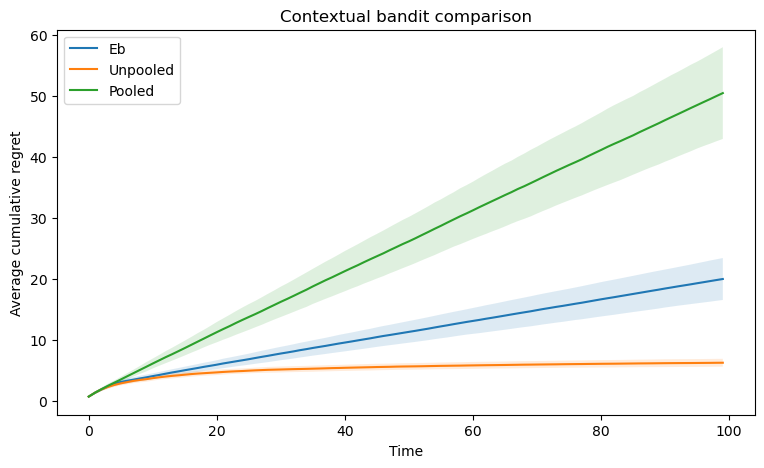

In [118]:
# high heterogeneity - unpooled wins
mu_a = np.array([
    [0.0,  0.5],   # arm 0
    [0.2, -0.2],   # arm 1
])

covariance = np.array([
    [[1.0,  0.2],
     [0.2,  0.5]],

    [[1.2, -0.1],
     [-0.1, 0.6]],
])

sigma_a = np.array([0.5, 0.5])

curves = compare_algorithms(
    algorithms = ("eb", "unpooled", "pooled"),
    n_runs = 20,
    n_participants = 50,
    T=100,
    p_context = 0.2,
    lam=1e-6,
    mu_a=mu_a,
    covariance=covariance,
    sigma_a=sigma_a
)

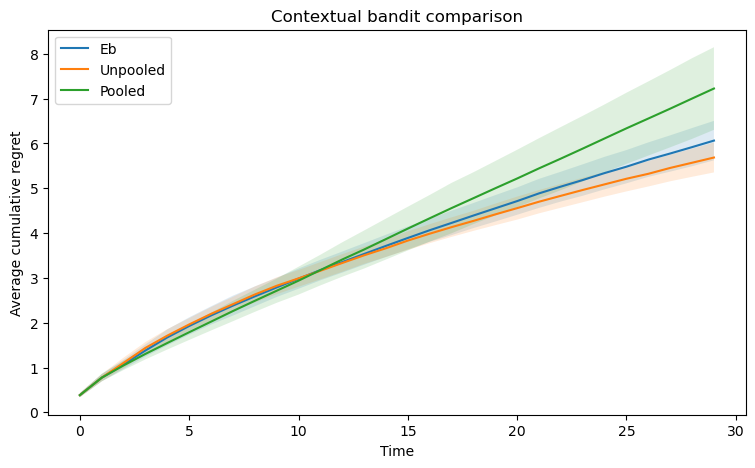

In [116]:
# moderate heterogeneity - EB SHOULD WIN 

mu = np.array([
    [0.0,  0.8],
    [0.3, -0.3],
])

Sigma = np.array([
    [[0.4,  0.05],
     [0.05, 0.15]],

    [[0.4, -0.05],
     [-0.05, 0.15]],
])

sigma_a = np.array([1.2, 1.2])

n_participants = 100
T = 30
p_context = 0.1

curves = compare_algorithms(
    algorithms = ("eb", "unpooled", "pooled"),
    n_runs = 20,
    n_participants = n_participants,
    T=T,
    p_context = 0.1,
    lam=1e-6,
    mu_a=mu_a,
    covariance=covariance,
    sigma_a=sigma_a
)

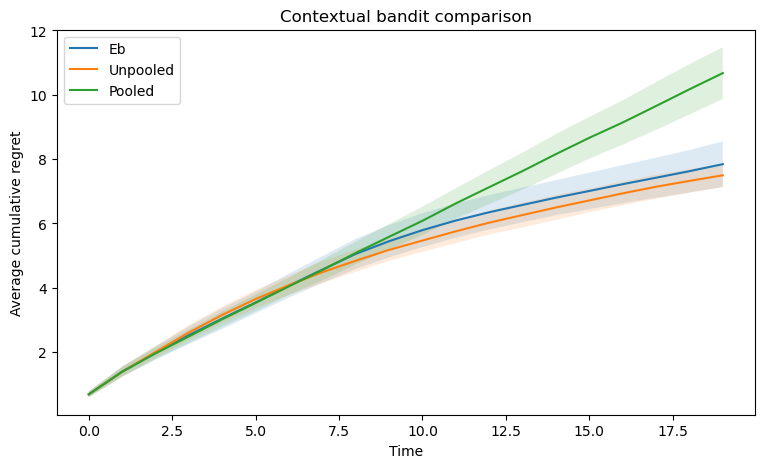

In [124]:
# EB FOR THE WIN 

mu = np.array([
    [0.0,  2.0],
    [0.2, -2.0],
])

Sigma = np.array([
    [[0.3,  0.0],
     [0.0,  1.5]],

    [[0.3,  0.0],
     [0.0,  1.5]],
])

sigma_a = np.array([1.5, 1.5])

n_participants = 150
T = 20
p_context = 0.5

curves = compare_algorithms(
    algorithms = ("eb", "unpooled", "pooled"),
    n_runs = 20,
    n_participants = n_participants,
    T=T,
    p_context = p_context,
    lam=1e-6,
    mu_a=mu_a,
    covariance=covariance,
    sigma_a=sigma_a
)

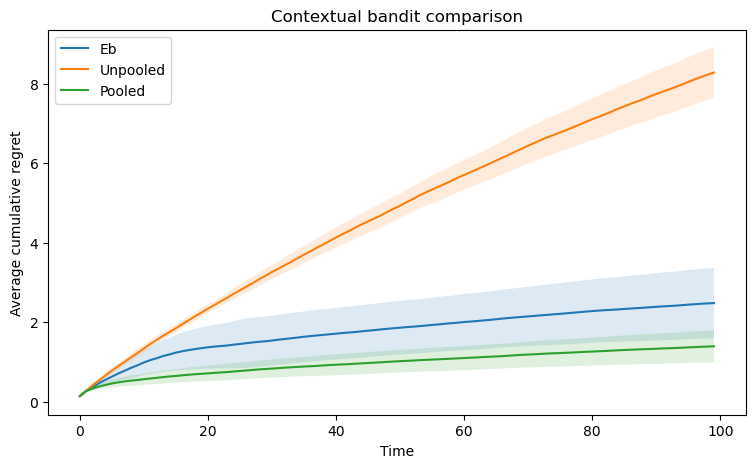

In [92]:
# low heterogeneity - pooling should win

mu = np.array([
    [0.0, 0.5],
    [0.2, -0.2],
])

Sigma = np.array([
    [[0.01, 0.0],
     [0.0,  0.01]],

    [[0.01, 0.0],
     [0.0,  0.01]],
])

sigma_a = np.array([1.0, 1.0])

curves = compare_algorithms(
    algorithms = ("eb", "unpooled", "pooled"),
    n_runs = 20,
    n_participants = 50,
    T=100,
    p_context = 0.2,
    lam=1e-6,
)

## Old Code - Not needed

In [108]:
    # def expected_reward(self, i: int, t: int, a: int) -> float:
    #     """
    #     E[R_{i,t}(a) | theta, c]
    #     """
    #     c_it = self.context[i, t]
    #     theta_i_a = self.theta[i, a]   # [theta_{i,a,0}, theta_{i,a,1}]
    #     return float(theta_i_a[0] + theta_i_a[1] * c_it)

    # def sample_reward(self, i: int, t: int, a: int) -> float:
    #     """
    #     Sample one realized reward:
    #         R_{i,t}(a) = expected_reward + eps
    #     """
    #     mean = self.expected_reward(i, t, a)
    #     eps = self.rng.normal(loc=0.0, scale=self.sigma_a[a])
    #     return float(mean + eps)

    # def best_arm(self, i: int, t: int) -> int:
    #     """
    #     Best arm under the true expected reward.
    #     """
    #     means = [self.expected_reward(i, t, a) for a in range(self.n_arms)]
    #     return int(np.argmax(means))

    # def best_expected_reward(self, i: int, t: int) -> float:
    #     """
    #     Maximum expected reward at (i,t).
    #     """
    #     return max(self.expected_reward(i, t, a) for a in range(self.n_arms))

    # def all_expected_rewards(self) -> np.ndarray:
    #     """
    #     Returns an array of shape (n_participants, T, n_arms)
    #     with the true conditional expected rewards.
    #     """
    #     out = np.zeros((self.n_participants, self.T, self.n_arms), dtype=float)
    #     for i in range(self.n_participants):
    #         for t in range(self.T):
    #             c_it = self.context[i, t]
    #             # vectorized across arms
    #             out[i, t, :] = self.theta[i, :, 0] + self.theta[i, :, 1] * c_it
    #     return out

In [110]:
# def simulate_random_policy(env: ContextualBanditEnvironment, seed = 0):
#     """
#     Very simple example policy:
#     choose an arm uniformly at random for each (i,t),
#     then compute realized reward and regret.
#     """
#     rng = np.random.default_rng(seed)

#     actions = np.zeros((env.n_participants, env.T), dtype=int)
#     rewards = np.zeros((env.n_participants, env.T), dtype=float)
#     regret = np.zeros((env.n_participants, env.T), dtype=float)

#     for i in range(env.n_participants):
#         for t in range(env.T):
#             a = int(rng.integers(env.n_arms))
#             r = env.sample_reward(i, t, a)

#             actions[i, t] = a
#             rewards[i, t] = r

#             best_mean = env.best_expected_reward(i, t)
#             chosen_mean = env.expected_reward(i, t, a)
#             regret[i, t] = best_mean - chosen_mean

#     return {
#         "actions": actions,
#         "rewards": rewards,
#         "regret": regret,
#         "cumulative_regret": regret.cumsum(axis=1),
#     }


# if __name__ == "__main__":
#     # Example with 2 arms
#     n = 50
#     T = 100
#     n_arms = 2

#     # Population-level hyperparameters for each arm
#     # mu[a] = [mu_{a,0}, mu_{a,1}]
#     mu_a = np.array([
#         [0.0,  0.5],   # arm 0
#         [0.3, -0.2],   # arm 1
#     ])

#     # Sigma[a] = 2x2 covariance for [theta_{i,a,0}, theta_{i,a,1}]
#     covariance = np.array([
#         [[1.0,  0.2],
#          [0.2,  0.5]],

#         [[1.2, -0.1],
#          [-0.1, 0.7]],
#     ])

#     # Individual-level noise std dev per arm
#     sigma_a = np.array([0.5, 0.5])

#     env = ContextualBanditEnvironment(
#         n_participants=n,
#         n_arms=n_arms,
#         T=T,
#         p_context=0.2,
#         mu_a=mu_a,
#         covariance=covariance,
#         sigma_a=sigma_a,
#         seed=0,
#     )

#     sim = simulate_random_policy(env, seed=123)

#     print("theta shape:", env.theta.shape)          # (n, n_arms, 2)
#     print("context shape:", env.context.shape)      # (n, T)
#     print("actions shape:", sim["actions"].shape)   # (n, T)
#     print("rewards shape:", sim["rewards"].shape)   # (n, T)

#     avg_final_regret = sim["cumulative_regret"][:, -1].mean()
#     print("Average final cumulative regret:", round(avg_final_regret, 4))

In [112]:
# def run_contextual_eb_simulation(
#     n_participants=50,
#     T=100,
#     p_context=0.2,
#     lam=1e-6,
#     seed=0
# ):
#     rng = np.random.default_rng(seed)

#     # True environment hyperparameters
#     mu_a = np.array([
#         [0.0,  0.5],   # arm 0: baseline, context effect
#         [0.2, -0.2],   # arm 1
#     ])

#     covariance = np.array([
#         [[1.0,  0.2],
#          [0.2,  0.5]],

#         [[1.2, -0.1],
#          [-0.1, 0.6]],
#     ])

#     sigma_a = np.array([0.5, 0.5])

#     env = ContextualEnvironment(
#         n_arms=2,
#         n_participants=n_participants,
#         T=T,
#         p_context=p_context,
#         mu_a=mu_a,
#         covariance=covariance,
#         sigma_a=sigma_a,
#         seed=seed
#     )

#     learner = RidgeLearningAlgorithm(
#         n_participants=n_participants,
#         lam=lam
#     )

#     eb_selector = EmpiricalBayesActionSelector()

#     cumulative_regret = np.zeros((n_participants, T))
#     actions = np.zeros((n_participants, T), dtype=int)
#     rewards = np.zeros((n_participants, T))

#     for t in range(T):
#         theta_hat, Sigma_hat, _ = learner.get_participant_estimates()

#         for i in range(n_participants):
#             x_it = env.context_vector(i, t)

#             # warm-up: random actions until some data exists
#             total_obs_i = sum(len(learner.y[(i, a)]) for a in range(2))
#             if total_obs_i < 2:
#                 a_sel = int(rng.integers(2))
#             else:
#                 a_sel, _ = eb_selector.choose_action(
#                     i=i,
#                     x_it=x_it,
#                     theta_hat=theta_hat,
#                     Sigma_hat=Sigma_hat,
#                     rng=rng
#                 )

#             r = env.sample_reward(i, t, a_sel)
#             learner.update(i, a_sel, x_it, r)

#             actions[i, t] = a_sel
#             rewards[i, t] = r
#             cumulative_regret[i, t] = env.regret(i, t, a_sel)

#     return {
#         "env": env,
#         "learner": learner,
#         "actions": actions,
#         "rewards": rewards,
#         "cumulative_regret": cumulative_regret.cumsum(axis=1),
#     }


# if __name__ == "__main__":
#     out = run_contextual_eb_simulation()
#     avg_final_regret = out["cumulative_regret"][:, -1].mean()
#     print("Average final cumulative regret:", round(avg_final_regret, 4))

#     avg_regret = out["cumulative_regret"].mean(axis=0)
    
#     plt.plot(avg_regret)
#     plt.xlabel("Time")
#     plt.ylabel("Average cumulative regret")
#     plt.title("EB Contextual Bandit")
#     plt.show()